# Mathematical Modeling

------------

## A. Set up card model

Enumerated attributes:

* Color
    * Red
    * Purple
    * Green
* Count
    * 1
    * 2
    * 3
* Fill
    * Solid
    * Striped
    * Open
* Shape
    * Capsule
    * Diamond
    * Squiggle

I think the best way is to number them instead of keeping string lables, and this is for two reasons. 

1. Pragmatic: indexing arrays is easy with numbers.
2. Semantic: All attributes are equal in function and importance.

In [111]:
import numpy as np
import random
from pprint import pprint
from itertools import combinations
from tqdm import tqdm
from collections import defaultdict, Counter
import matplotlib.pyplot as plt


from visualize_cards import Card

1. establish the cardspace

In [2]:
size = 3
grid = np.array([[[[i for i in range(size)] for _ in range(size)] for _ in range(size)] for _ in range(size)])
grid

array([[[[0, 1, 2],
         [0, 1, 2],
         [0, 1, 2]],

        [[0, 1, 2],
         [0, 1, 2],
         [0, 1, 2]],

        [[0, 1, 2],
         [0, 1, 2],
         [0, 1, 2]]],


       [[[0, 1, 2],
         [0, 1, 2],
         [0, 1, 2]],

        [[0, 1, 2],
         [0, 1, 2],
         [0, 1, 2]],

        [[0, 1, 2],
         [0, 1, 2],
         [0, 1, 2]]],


       [[[0, 1, 2],
         [0, 1, 2],
         [0, 1, 2]],

        [[0, 1, 2],
         [0, 1, 2],
         [0, 1, 2]],

        [[0, 1, 2],
         [0, 1, 2],
         [0, 1, 2]]]])

2. Function to detect if any set of coords is a set

There are only three states, so no need to get fancy with the linalg.

In [85]:
def check_colinearity(a, b, c):
    lengths = [len(set([x[dim] for x in (a, b, c)])) for dim in range(4)]
    if 2 in lengths:
        return False, 0
    else:
        return True, lengths.count(1)

In [92]:
tests = [[[0, 0, 0, 0], [0, 0, 0, 1], [0, 0, 0, 2]], 
         [[0, 0, 0, 0], [0, 0, 0, 1], [0, 0, 0, 1]],
         [[1, 1, 1, 1], [0, 0, 0, 0], [2, 2, 2, 2]],
         [[0, 1, 2, 0], [1, 1, 2, 1], [2, 1, 2, 2]], 
         [[0, 1, 2, 0], [1, 1, 2, 1], [2, 2, 2, 2]]]

answers = [True, False, True, True, False]

for t, a in zip(tests, answers):
    if (outcome := check_colinearity(*t))[0] == a:
        print('pass', outcome)
    else:
        print('fail', outcome)

pass (True, 3)
pass (False, 0)
pass (True, 0)
pass (True, 2)
pass (False, 0)


## B. How many sets of 12 don't have any sets?

for any given 3 cards amongst any given 12 cards, 

In [93]:
choices = [0, 1, 2]

for _ in range(4):
    random_dims = [random.choice(choices) for _ in range(4)]
    print(random_dims)
    random_card = Card(random_dims)
    pprint(random_card.__dict__)
    
    for i in random_card.vis:
        print(i)

[1, 2, 0, 1]
{'color': 'green',
 'fill': 'empty',
 'number': 2,
 'shape': 'squiggle',
 'vis': ['\x1b┌───┐\x1b',
         '\x1b│╔☐╝│\x1b',
         '\x1b│   │\x1b',
         '\x1b│╔☐╝│\x1b',
         '\x1b└───┘\x1b']}
┌───┐
│╔☐╝│
│   │
│╔☐╝│
└───┘
[2, 2, 0, 0]
{'color': 'green',
 'fill': 'empty',
 'number': 3,
 'shape': 'diamond',
 'vis': ['\x1b┌───┐\x1b',
         '\x1b│<☐>│\x1b',
         '\x1b│<☐>│\x1b',
         '\x1b│<☐>│\x1b',
         '\x1b└───┘\x1b']}
┌───┐
│<☐>│
│<☐>│
│<☐>│
└───┘
[0, 2, 1, 0]
{'color': 'green',
 'fill': 'stripe',
 'number': 1,
 'shape': 'diamond',
 'vis': ['\x1b┌───┐\x1b',
         '\x1b│   │\x1b',
         '\x1b│<▥>│\x1b',
         '\x1b│   │\x1b',
         '\x1b└───┘\x1b']}
┌───┐
│   │
│<▥>│
│   │
└───┘
[1, 1, 0, 1]
{'color': 'purple',
 'fill': 'empty',
 'number': 2,
 'shape': 'squiggle',
 'vis': ['\x1b┌───┐\x1b',
         '\x1b│╔☐╝│\x1b',
         '\x1b│   │\x1b',
         '\x1b│╔☐╝│\x1b',
         '\x1b└───┘\x1b']}
┌───┐
│╔☐╝│
│   │
│╔☐╝│
└───┘


In [94]:
def display_grid(twelve):
    for row_idxs in [list(range(4)), list(range(4, 8)), list(range(8, 12))]:
        # print(row_idxs)
        print('' + '   '.join([f'{i}'.rjust(3) for i in row_idxs]))
        cards = list(map(lambda x: Card(twelve[x]), row_idxs))
        for line in range(5):
            line = [f'{card.vis[line]} ' for card in cards]
            print(''.join(line))

In [ ]:
def count_sets(twelve):
    sets = 0
    for comb in combinations(range(12), 3):
        cards = [twelve[c] for c in comb]
        set_found = check_colinearity(*cards)[0]
        if set_found:
            sets += 1
    return sets

In [106]:
random_12 = {j: [random.choice(choices) for _ in range(4)] for j in range(12)}
# pprint(random_12)

display_grid(random_12)

counts = count_sets(random_12)
print(f'\n{counts} Sets Found:')
for comb in combinations(range(12), 3):
    cards = [random_12[c] for c in comb]
    set_found, count = check_colinearity(*cards)
    if set_found:
        print(comb, count)


  0     1     2     3
┌───┐ ┌───┐ ┌───┐ ┌───┐ 
│<▥>│ │╔☐╝│ │╔■╝│ │   │ 
│<▥>│ │╔☐╝│ │╔■╝│ │╔■╝│ 
│<▥>│ │╔☐╝│ │╔■╝│ │   │ 
└───┘ └───┘ └───┘ └───┘ 
  4     5     6     7
┌───┐ ┌───┐ ┌───┐ ┌───┐ 
│╔▥╝│ │╔☐╝│ │(▥)│ │(■)│ 
│╔▥╝│ │   │ │(▥)│ │   │ 
│╔▥╝│ │╔☐╝│ │(▥)│ │(■)│ 
└───┘ └───┘ └───┘ └───┘ 
  8     9    10    11
┌───┐ ┌───┐ ┌───┐ ┌───┐ 
│   │ │╔☐╝│ │   │ │(▥)│ 
│╔▥╝│ │╔☐╝│ │<■>│ │(▥)│ 
│   │ │╔☐╝│ │   │ │(▥)│ 
└───┘ └───┘ └───┘ └───┘ 

4 Sets Found:
(0, 4, 6) 2
(2, 4, 9) 3
(2, 7, 10) 1
(5, 10, 11) 1


I wonder how low it will take to iterate through every set of 12... 
Way too long. 

There are over 707 billion possible boards. It takes about 6:23 to do 1e6, which means it would take about 8.5 years 


Gotta sample it. 

In [119]:
total_boards = 707_243_201_847
every_possible_card = [] #81 cards, not too much RAM
for a in range(3):
    for b in range(3):
        for c in range(3):
            for d in range(3):
                every_possible_card.append([a, b, c, d])

set_counter = defaultdict(int)
trials = int(1e5)
for _ in tqdm(range(trials)):
    combo = random.sample(every_possible_card, 12)
# for combo in tqdm(combinations(every_possible_card, 12)):
    n_sets = count_sets(combo)
    set_counter[n_sets] += 1
    # if counter % int(1e9) == 0:
    #     print(f'{100*(counter/total_boards)}%' )

outcomes = {k: 100*(v/trials) for k, v in set_counter.items()}
pprint(outcomes)

100%|██████████| 100000/100000 [00:38<00:00, 2607.25it/s]

{0: 3.254,
 1: 14.530000000000001,
 2: 26.165,
 3: 27.409,
 4: 17.927,
 5: 7.921,
 6: 2.226,
 7: 0.483,
 8: 0.074,
 9: 0.009000000000000001,
 10: 0.002}


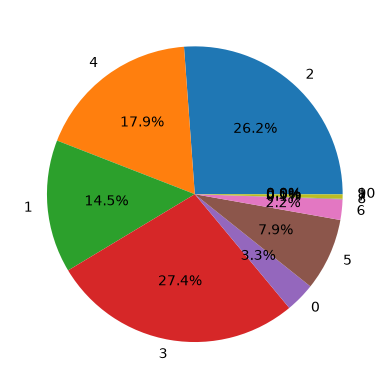

In [120]:
labels = outcomes.keys()
sizes = outcomes.values()

fix, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct='%1.1f%%')